In [1]:
import pandas as pd
import numpy as np

# Visualization (for later)
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [2]:
matches = pd.read_csv("C:/Users/Rashmitha/Desktop/IPL_Sports_Analytics/data/matches.csv")
deliveries = pd.read_csv("C:/Users/Rashmitha/Desktop/IPL_Sports_Analytics/data/deliveries.csv")
print("Matches shape:", matches.shape)
print("Deliveries shape:", deliveries.shape)

Matches shape: (1095, 20)
Deliveries shape: (260920, 17)


In [3]:
matches.head()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,18-04-2008,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,19-04-2008,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,19-04-2008,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,20-04-2008,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,20-04-2008,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


In [4]:
deliveries.head()

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


In [5]:
matches.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               1095 non-null   int64  
 1   season           1095 non-null   object 
 2   city             1044 non-null   object 
 3   date             1095 non-null   object 
 4   match_type       1095 non-null   object 
 5   player_of_match  1090 non-null   object 
 6   venue            1095 non-null   object 
 7   team1            1095 non-null   object 
 8   team2            1095 non-null   object 
 9   toss_winner      1095 non-null   object 
 10  toss_decision    1095 non-null   object 
 11  winner           1090 non-null   object 
 12  result           1095 non-null   object 
 13  result_margin    1076 non-null   float64
 14  target_runs      1092 non-null   float64
 15  target_overs     1092 non-null   float64
 16  super_over       1095 non-null   object 
 17  method        

In [6]:
deliveries.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260920 entries, 0 to 260919
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   match_id          260920 non-null  int64 
 1   inning            260920 non-null  int64 
 2   batting_team      260920 non-null  object
 3   bowling_team      260920 non-null  object
 4   over              260920 non-null  int64 
 5   ball              260920 non-null  int64 
 6   batter            260920 non-null  object
 7   bowler            260920 non-null  object
 8   non_striker       260920 non-null  object
 9   batsman_runs      260920 non-null  int64 
 10  extra_runs        260920 non-null  int64 
 11  total_runs        260920 non-null  int64 
 12  extras_type       14125 non-null   object
 13  is_wicket         260920 non-null  int64 
 14  player_dismissed  12950 non-null   object
 15  dismissal_kind    12950 non-null   object
 16  fielder           9354 non-null    obj

In [21]:
print("Matches columns:\n", matches.columns)
print("\nDeliveries columns:\n", deliveries.columns)

Matches columns:
 Index(['id', 'city', 'winner', 'target_runs'], dtype='object')

Deliveries columns:
 Index(['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball',
       'batter', 'bowler', 'non_striker', 'batsman_runs', 'extra_runs',
       'total_runs', 'extras_type', 'is_wicket', 'player_dismissed',
       'dismissal_kind', 'fielder'],
      dtype='object')


In [22]:
# Fix team name inconsistencies
teams_map = {
    'Delhi Daredevils': 'Delhi Capitals',
    'Kings XI Punjab': 'Punjab Kings'
}

matches.replace(teams_map, inplace=True)
deliveries.replace(teams_map, inplace=True)

# Remove matches with no result
matches = matches[matches['winner'].notna()]

# Fill missing city
matches['city'].fillna('Unknown', inplace=True)

In [23]:
print(matches.isnull().sum())
print(deliveries.isnull().sum())

id             0
city           0
winner         0
target_runs    0
dtype: int64
match_id                 0
inning                   0
batting_team             0
bowling_team             0
over                     0
ball                     0
batter                   0
bowler                   0
non_striker              0
batsman_runs             0
extra_runs               0
total_runs               0
extras_type         246795
is_wicket                0
player_dismissed    247970
dismissal_kind      247970
fielder             251566
dtype: int64


In [24]:
matches = matches[['id', 'city', 'winner', 'target_runs']]

In [25]:
df = deliveries.merge(matches, left_on='match_id', right_on='id')

In [26]:
print(df.shape)
df[['match_id', 'id']].head()

(260430, 21)


,match_id,id
0,335982,335982
1,335982,335982
2,335982,335982
3,335982,335982
4,335982,335982


In [28]:
df.drop(columns=['id'], inplace=True)

In [29]:
print(df.columns)

Index(['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball',
       'batter', 'bowler', 'non_striker', 'batsman_runs', 'extra_runs',
       'total_runs', 'extras_type', 'is_wicket', 'player_dismissed',
       'dismissal_kind', 'fielder', 'city', 'winner', 'target_runs'],
      dtype='object')


In [30]:
df = df[df['inning'] == 2]

In [31]:
df['current_score'] = df.groupby('match_id')['total_runs'].cumsum()

In [32]:
df['wickets'] = df.groupby('match_id')['is_wicket'].cumsum()

In [33]:
df['balls_bowled'] = df.groupby('match_id').cumcount() + 1

In [34]:
df['runs_left'] = df['target_runs'] - df['current_score']

In [35]:
df['balls_left'] = 120 - df['balls_bowled']

In [36]:
df[['current_score','runs_left','balls_left','wickets']].head()

,current_score,runs_left,balls_left,wickets
124,1,222.0,119,0
125,2,221.0,118,0
126,2,221.0,117,0
127,3,220.0,116,0
128,4,219.0,115,0


In [37]:
df['wickets_left'] = 10 - df['wickets']

In [38]:
df['crr'] = df['current_score'] / (df['balls_bowled'] / 6)

In [39]:
df['rrr'] = (df['runs_left'] * 6) / df['balls_left']

In [40]:
df = df[df['balls_left'] != 0]

In [42]:
df['result'] = (df['batting_team'] == df['winner']).astype(int)

In [43]:
df[['crr','rrr','wickets_left','result']].head()

,crr,rrr,wickets_left,result
124,6.0,11.193277,10,0
125,6.0,11.237288,10,0
126,4.0,11.333333,10,0
127,4.5,11.379310,10,0
128,4.8,11.426087,10,0


In [44]:
final_df = df[['batting_team','bowling_team','city',
               'runs_left','balls_left','wickets_left',
               'crr','rrr','result']]

In [45]:
final_df = final_df.dropna()

In [64]:
final_df = final_df[final_df['balls_left'] > 6]

In [65]:
# Shuffle (important)
final_df = final_df.sample(frac=1, random_state=42)

# Split
X = final_df.drop('result', axis=1)
y = final_df['result']

In [66]:
print(final_df['balls_left'].min())

7


In [46]:
print(final_df.shape)
final_df.head()

(125093, 9)


,batting_team,bowling_team,city,runs_left,balls_left,wickets_left,crr,rrr,result
124,Royal Challengers Bangalore,Kolkata Knight Riders,Bangalore,222.0,119,10,6.0,11.193277,0
125,Royal Challengers Bangalore,Kolkata Knight Riders,Bangalore,221.0,118,10,6.0,11.237288,0
126,Royal Challengers Bangalore,Kolkata Knight Riders,Bangalore,221.0,117,10,4.0,11.333333,0
127,Royal Challengers Bangalore,Kolkata Knight Riders,Bangalore,220.0,116,10,4.5,11.379310,0
128,Royal Challengers Bangalore,Kolkata Knight Riders,Bangalore,219.0,115,10,4.8,11.426087,0


In [47]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in ['batting_team','bowling_team','city']:
    final_df[col] = le.fit_transform(final_df[col])

In [48]:
X = final_df.drop('result', axis=1)
y = final_df['result']

In [49]:
print(X.head())
print(y.head())

     batting_team  bowling_team  city  runs_left  balls_left  wickets_left  \
124            14             6     2      222.0         119            10   
125            14             6     2      221.0         118            10   
126            14             6     2      221.0         117            10   
127            14             6     2      220.0         116            10   
128            14             6     2      219.0         115            10   

     crr        rrr  
124  6.0  11.193277  
125  6.0  11.237288  
126  4.0  11.333333  
127  4.5  11.379310  
128  4.8  11.426087  
124    0
125    0
126    0
127    0
128    0
Name: result, dtype: int32


In [50]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (100074, 8)
Test: (25019, 8)


In [87]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [88]:
y_prob_lr = lr.predict_proba(X_test)[:,1]

In [52]:
from sklearn.metrics import accuracy_score, roc_auc_score

print("LR Accuracy:", accuracy_score(y_test, y_pred_lr))
print("LR ROC-AUC:", roc_auc_score(y_test, y_pred_lr))

LR Accuracy: 0.77792877413166
LR ROC-AUC: 0.7769917358212876


In [72]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:,1]

print("RF Accuracy:", accuracy_score(y_test, y_pred_rf))
print("RF ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

RF Accuracy: 0.8467964347096207
RF ROC-AUC: 0.9314530431465221


In [75]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:,1]

print("XGB Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("XGB ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))

XGB Accuracy: 0.8881250249810144
XGB ROC-AUC: 0.9609447508439058


In [61]:
y_pred_xgb = xgb_model.predict(X_test)

In [62]:
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("XGBoost ROC-AUC:", roc_auc_score(y_test, y_pred_xgb))

XGBoost Accuracy: 0.8881250249810144
XGBoost ROC-AUC: 0.8874388362685709


In [92]:
import pickle

pickle.dump(xgb_model, open("model.pkl", "wb"))

In [63]:
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))

Logistic Regression Accuracy: 0.77792877413166
Random Forest Accuracy: 0.8467964347096207
XGBoost Accuracy: 0.8881250249810144


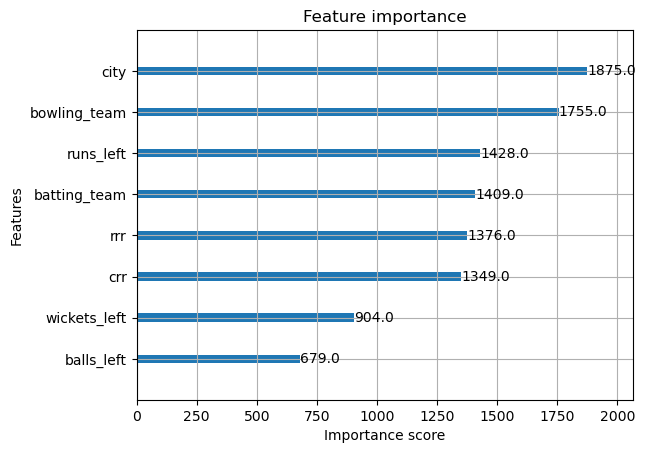

In [59]:
import matplotlib.pyplot as plt
xgb.plot_importance(xgb_model)
plt.show()

In [76]:
player_df = deliveries.copy()

In [77]:
player_stats = player_df.groupby('batter').agg({
    'batsman_runs': 'sum',
    'ball': 'count'
}).reset_index()

player_stats.rename(columns={
    'batsman_runs': 'runs',
    'ball': 'balls'
}, inplace=True)

In [78]:
player_stats['strike_rate'] = (player_stats['runs'] / player_stats['balls']) * 100

In [79]:
player_stats = player_stats[player_stats['balls'] > 100]

In [80]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42)
player_stats['cluster'] = kmeans.fit_predict(
    player_stats[['runs','strike_rate']]
)

In [81]:
player_stats.head()

,batter,runs,balls,strike_rate,cluster
0,A Ashish Reddy,280,196,142.857143,1
1,A Badoni,634,505,125.544554,1
9,A Manohar,231,181,127.624309,1
10,A Mishra,381,440,86.590909,1
15,A Raghuvanshi,163,109,149.541284,1


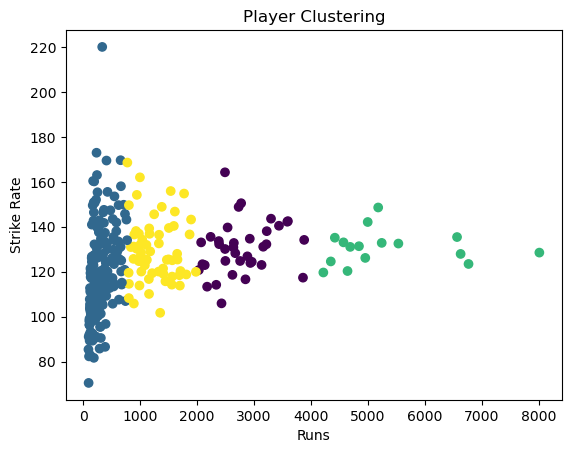

In [82]:
import matplotlib.pyplot as plt

plt.scatter(player_stats['runs'], player_stats['strike_rate'],
            c=player_stats['cluster'])

plt.xlabel("Runs")
plt.ylabel("Strike Rate")
plt.title("Player Clustering")
plt.show()

In [83]:
print("Final Model Comparison:")
print("Logistic:", accuracy_score(y_test, y_pred_lr))
print("Random Forest:", accuracy_score(y_test, y_pred_rf))
print("XGBoost:", accuracy_score(y_test, y_pred_xgb))

Final Model Comparison:
Logistic: 0.77792877413166
Random Forest: 0.8467964347096207
XGBoost: 0.8881250249810144


In [89]:
print("\nROC-AUC Comparison:")
print("Logistic:", roc_auc_score(y_test, y_prob_lr))
print("Random Forest:", roc_auc_score(y_test, y_prob_rf))
print("XGBoost:", roc_auc_score(y_test, y_prob_xgb))


ROC-AUC Comparison:
Logistic: 0.8618717921392289
Random Forest: 0.9314530431465221
XGBoost: 0.9609447508439058


In [90]:
import pickle

pickle.dump(xgb_model, open("model.pkl", "wb"))

In [91]:
model = pickle.load(open("model.pkl", "rb"))